In [9]:
import pandas as pd

data = {
    'Name': ['Alice', 'Bob', 'Charlie', 'David', 'Eve', 'Frank', 'Grace', 'Hannah', 'Ian', 'Judy'],
    'Salary': [3200, 3400, 3100, 8000, 3300, 3600, 9000, 3000, 3400, 9500],
    'Age': [25, 28, 26, 27, 29, 30, 26, 31, 32, 28]
}

df = pd.DataFrame(data)
df

,Name,Salary,Age
0,Alice,3200,25
1,Bob,3400,28
2,Charlie,3100,26
3,David,8000,27
4,Eve,3300,29
5,Frank,3600,30
6,Grace,9000,26
7,Hannah,3000,31
8,Ian,3400,32
9,Judy,9500,28


## 정규화와 표준화
### 정규화(Normalization)란?
- 데이터의 값을 0~1 범위로 압축하여 동일한 스케일로 맞추는 작업
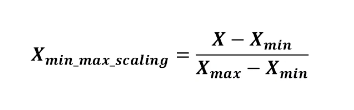 <br>
현재값에서 최소값 / 데이터가 퍼져 있는 총길이(전체 범위)
최소 값 배우는 이유 (출발선을 0으로 맞추는 원점이동)

### 표준화(Standardization)란?
- 데이터의 값을 평균이 0, 표준편차가 1이 되도록 변환하는 기법 <br>
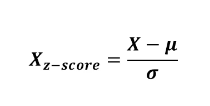 <br>
편차(현재값 - 평균) / 표준편차 => 현재 값이 평균으로부터 표준편차의 몇 배만큼 떨어져 있는가? 
현재값에서 평균 빼는 이유 ( 내 점수의 위치를 0으로 )

In [13]:
# Min-Max 정규화
norm = (df['Salary'] - df['Salary'].min()) / (df['Salary'].max() - df['Salary'].min())
df['정규화'] = norm

# Z-score 표준화
stand = (df['Salary'] - df['Salary'].mean()) / (df['Salary'].std())
df['표준화'] = stand

df

,Name,Salary,Age,정규화,표준화
0,Alice,3200,25,0.030769,-0.646010
1,Bob,3400,28,0.061538,-0.572180
2,Charlie,3100,26,0.015385,-0.682925
3,David,8000,27,0.769231,1.125903
4,Eve,3300,29,0.046154,-0.609095
5,Frank,3600,30,0.092308,-0.498351
6,Grace,9000,26,0.923077,1.495052
7,Hannah,3000,31,0.000000,-0.719840
8,Ian,3400,32,0.061538,-0.572180
9,Judy,9500,28,1.000000,1.679626


> 위와 같이 공식으로 구현해도 되지만, 빅분기 실기 시험에선 사이킷런(sklearn) 라이브러리를 사용한다.

### 사이킷런으로 정규화와 표준화
- Scikit-learn의 MinMaxScaler와 StandardScaler를 사용하면 정규화와 표준화를 쉽게 수행 가능하다.
- `fit_transform()`으로 바로 적용 가능
    - fit: 학습, transform: 변환
- 2차원 형태로 넣어야 함: `[['salary']]`
    - fit_transform() 안에 DataFrame 즉, 2차원 배열을 기대하기 때문에!

In [ ]:
pip install scikit-learn

In [19]:
import sklearn
print(dir(sklearn))
print(dir(sklearn.preprocessing))

['calibration', 'clone', 'cluster', 'compose', 'config_context', 'covariance', 'cross_decomposition', 'datasets', 'decomposition', 'discriminant_analysis', 'dummy', 'ensemble', 'exceptions', 'experimental', 'externals', 'feature_extraction', 'feature_selection', 'frozen', 'gaussian_process', 'get_config', 'impute', 'inspection', 'isotonic', 'kernel_approximation', 'kernel_ridge', 'linear_model', 'manifold', 'metrics', 'mixture', 'model_selection', 'multiclass', 'multioutput', 'naive_bayes', 'neighbors', 'neural_network', 'pipeline', 'preprocessing', 'random_projection', 'semi_supervised', 'set_config', 'show_versions', 'svm', 'tree']
['Binarizer', 'FunctionTransformer', 'KBinsDiscretizer', 'KernelCenterer', 'LabelBinarizer', 'LabelEncoder', 'MaxAbsScaler', 'MinMaxScaler', 'MultiLabelBinarizer', 'Normalizer', 'OneHotEncoder', 'OrdinalEncoder', 'PolynomialFeatures', 'PowerTransformer', 'QuantileTransformer', 'RobustScaler', 'SplineTransformer', 'StandardScaler', 'TargetEncoder', '__all__

In [24]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler
# scaler 크기나 범위를 조절해 주는 도구

# 에시 데이터
df = pd.DataFrame({'Salary' : [1000, 2000, 3000, 4000, 5000]})

# 정규화
scaler_minmax = MinMaxScaler()
df['정규화'] = scaler_minmax.fit_transform(df[['Salary']])

# 표준화
scaler_standard = StandardScaler()
df['표준화'] = scaler_standard.fit_transform(df[['Salary']])

df

,Salary,정규화,표준화
0,1000,0.00,-1.414214
1,2000,0.25,-0.707107
2,3000,0.50,0.000000
3,4000,0.75,0.707107
4,5000,1.00,1.414214
